# Titanic survive prediction with supervised ML

## Loading all required libraries

In [288]:
import os 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.model_selection import (
    StratifiedKFold, 
    GridSearchCV,
    train_test_split
)
from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    roc_auc_score,
    precision_score
)

from xgboost import XGBClassifier


## Load train, test data

In [289]:
cwd = os.getcwd()
path = os.path.join(cwd, 'data')

cols_to_keep = [
    'Pclass',
    'Sex',
    'Age',
    'SibSp',
    'Parch',
    'Fare',
    'Embarked'
]

df_train, df_test = (
    pd.read_csv(os.path.join(path, 'train.csv')).set_index('PassengerId')[cols_to_keep + ['Survived']],
    pd.read_csv(os.path.join(path, 'test.csv')).set_index('PassengerId')[cols_to_keep]
)


In [290]:
df_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
PassengerId,,,,,,,,
1,3,male,22.0,1,0,7.2500,S,0
2,1,female,38.0,1,0,71.2833,C,1
3,3,female,26.0,0,0,7.9250,S,1
4,1,female,35.0,1,0,53.1000,S,1
5,3,male,35.0,0,0,8.0500,S,0
...,...,...,...,...,...,...,...,...
887,2,male,27.0,0,0,13.0000,S,0
888,1,female,19.0,0,0,30.0000,S,1
889,3,female,NaN,1,2,23.4500,S,0


In [291]:
df_test

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,
892,3,male,34.5,0,0,7.8292,Q
893,3,female,47.0,1,0,7.0000,S
894,2,male,62.0,0,0,9.6875,Q
895,3,male,27.0,0,0,8.6625,S
896,3,female,22.0,1,1,12.2875,S
...,...,...,...,...,...,...,...
1305,3,male,NaN,0,0,8.0500,S
1306,1,female,39.0,0,0,108.9000,C
1307,3,male,38.5,0,0,7.2500,S


## Cleaning datasets

In [293]:
def cleaning_dfs(df):
    '''Func for cleaning train and test dfs'''

    df_ = df.copy()
    df_cleaned = df_.fillna(df_.median(numeric_only=True)).dropna()

    print(f'Df before cleaning \n{df_.isna().sum()}\nShape: {df_.shape}\n')
    print(f'Df after cleaning \n{df_cleaned.isna().sum()}\nShape: {df_cleaned.shape}\n')

    return df_cleaned

print('Train cleaning....')
df_train_c = cleaning_dfs(df_train)

print('Test cleaning....')
df_test_c = cleaning_dfs(df_test)

Train cleaning....
Df before cleaning 
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
Survived      0
dtype: int64
Shape: (891, 8)

Df after cleaning 
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
Survived    0
dtype: int64
Shape: (889, 8)

Test cleaning....
Df before cleaning 
Pclass       0
Sex          0
Age         86
SibSp        0
Parch        0
Fare         1
Embarked     0
dtype: int64
Shape: (418, 7)

Df after cleaning 
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
Shape: (418, 7)



## EDA train df

In [294]:
# info df
df_train_c.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 1 to 891
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    889 non-null    int64  
 1   Sex       889 non-null    str    
 2   Age       889 non-null    float64
 3   SibSp     889 non-null    int64  
 4   Parch     889 non-null    int64  
 5   Fare      889 non-null    float64
 6   Embarked  889 non-null    str    
 7   Survived  889 non-null    int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 62.5 KB


In [295]:
# info about numeric data
df_train_c.describe()

,Pclass,Age,SibSp,Parch,Fare,Survived
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,2.311586,29.315152,0.524184,0.382452,32.096681,0.382452
std,0.834700,12.984932,1.103705,0.806761,49.697504,0.486260
min,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,22.000000,0.000000,0.000000,7.895800,0.000000
50%,3.000000,28.000000,0.000000,0.000000,14.454200,0.000000
75%,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000
max,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000


Text(0.5, 1.0, 'Alive vs Dead')

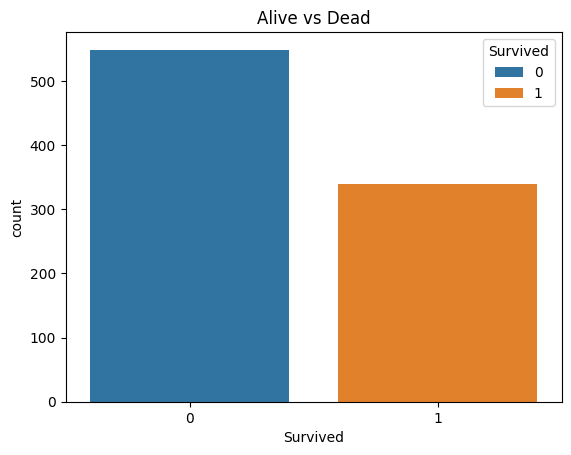

In [296]:
# Alived vs Dead
sns.countplot(data=df_train_c, x='Survived', hue='Survived')
plt.title('Alive vs Dead')

Text(0.5, 1.0, 'male and female alived')

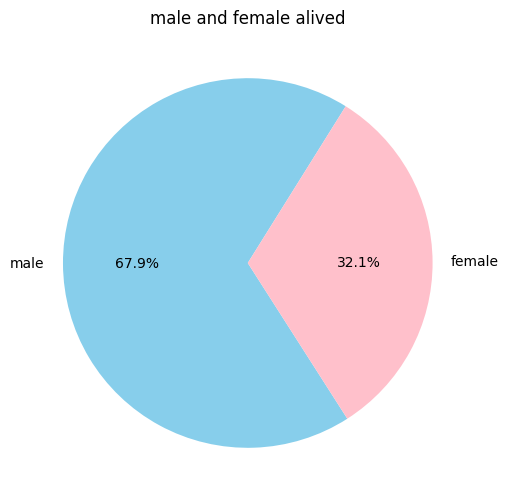

In [297]:
# Male vs Female who alived
survived_by_sex = df_train_c.groupby("Sex")["Survived"].sum()  # number of alived

fig, axs = plt.subplots(figsize=(6, 6), dpi=100)
axs.pie(
    survived_by_sex,
    labels=df_train_c['Sex'].unique(),
    autopct="%1.1f%%",
    startangle=58,
    colors=["skyblue", "pink"]
)
axs.set_title('male and female alived')

Text(0.5, 1.0, 'Port of embarkation')

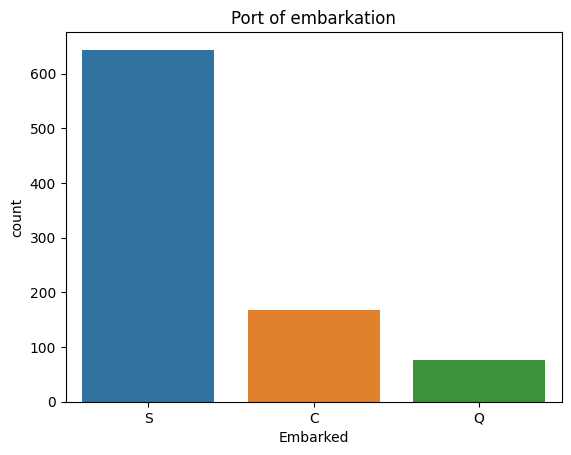

In [298]:
# Port of embarkation
sns.countplot(data=df_train_c, x='Embarked', hue='Embarked')
plt.title('Port of embarkation')

Text(0.5, 1.0, 'People class')

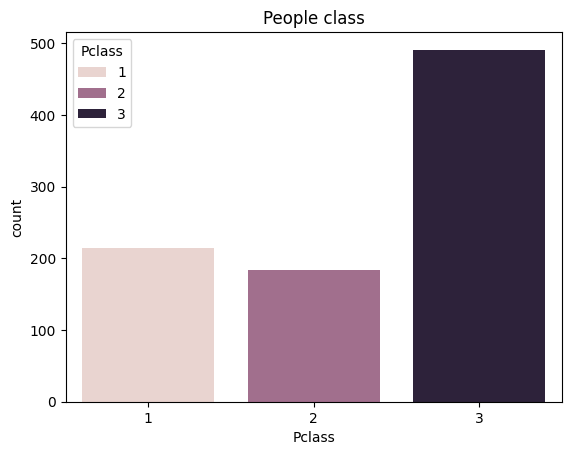

In [299]:
# People class
sns.countplot(data=df_train_c, x='Pclass', hue='Pclass')
plt.title('People class')

## Encoding str data

In [ ]:
def encoding_str_data(df):
    ''' Func for encoding string data '''
    df_ = df.copy()

    cat_cols = df_.select_dtypes(include='str')

    for col in cat_cols:
        le = LabelEncoder()
        df_[col] = le.fit_transform(df_[col])

    return df_


df_train_encoded = encoding_str_data(df_train_c)
df_test_encoded = encoding_str_data(df_test_c)
    

In [301]:
df_train_encoded

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
PassengerId,,,,,,,,
1,3,1,22.0,1,0,7.2500,2,0
2,1,0,38.0,1,0,71.2833,0,1
3,3,0,26.0,0,0,7.9250,2,1
4,1,0,35.0,1,0,53.1000,2,1
5,3,1,35.0,0,0,8.0500,2,0
...,...,...,...,...,...,...,...,...
887,2,1,27.0,0,0,13.0000,2,0
888,1,0,19.0,0,0,30.0000,2,1
889,3,0,28.0,1,2,23.4500,2,0


In [302]:
df_test_encoded

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,
892,3,1,34.5,0,0,7.8292,1
893,3,0,47.0,1,0,7.0000,2
894,2,1,62.0,0,0,9.6875,1
895,3,1,27.0,0,0,8.6625,2
896,3,0,22.0,1,1,12.2875,2
...,...,...,...,...,...,...,...
1305,3,1,27.0,0,0,8.0500,2
1306,1,0,39.0,0,0,108.9000,0
1307,3,1,38.5,0,0,7.2500,2


## Spliting df_train_encoded to Train and Test

In [303]:
X = df_train_encoded.drop('Survived', axis=1)
y = df_train_encoded['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=20)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=20) # for grid search

## Decision Tree model

#### Searching best params

In [304]:
clf = GridSearchCV(
    estimator=Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', DecisionTreeClassifier(random_state=20))
        ]
    ),
    param_grid={
        'model__criterion'     : ['gini', 'entropy'],
        'model__max_depth'     : [2, 3, 4, 5],
        'model__max_leaf_nodes': [2, 3, 4, 5]
    },
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)
clf.fit(X_train, y_train)

print(f'Best params for Decision Tree: {clf.best_params_}\n Best score: {clf.best_score_}')



Best params for Decision Tree: {'model__criterion': 'gini', 'model__max_depth': 3, 'model__max_leaf_nodes': 5}
 Best score: 0.7861935483870968


#### Training with best params

In [305]:
models_test_accuracy = {}

clf = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', DecisionTreeClassifier(
            criterion='gini',
            max_depth=3, 
            max_leaf_nodes=5, 
            random_state=20
        ))
    ]
)
clf.fit(X_train, y_train)
pred_clf = clf.predict(X_test)

models_test_accuracy['Decision Tree score'] = clf.score(X_test, y_test)

print(f'Scores:\nAccuracy train: {clf.score(X_train, y_train)}\nAccuracy test {clf.score(X_test, y_test)}')
print(f'Precision: {precision_score(y_test, pred_clf)}\nRecall: {recall_score(y_test, pred_clf)}\nROC-AUC: {roc_auc_score(y_test, pred_clf)}')


Scores:
Accuracy train: 0.7942122186495176
Accuracy test 0.7865168539325843
Precision: 0.8666666666666667
Recall: 0.5148514851485149
ROC-AUC: 0.7333293570320887


## Random forest model

#### Searching best params

In [306]:
clf = GridSearchCV(
    estimator=Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', RandomForestClassifier(random_state=20))
        ]
    ),
    param_grid={
        'model__n_estimators'   : [10, 30, 50, 70, 100],
        'model__criterion'     : ['gini', 'entropy'],
        'model__max_depth'     : [2, 3, 4, 5],
        'model__max_leaf_nodes': [2, 3, 4, 5]
    },
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

print(f'Best params for Random forest: {clf.best_params_}\n Best score: {clf.best_score_}')

Best params for Random forest: {'model__criterion': 'entropy', 'model__max_depth': 2, 'model__max_leaf_nodes': 3, 'model__n_estimators': 50}
 Best score: 0.7910064516129032


In [307]:
clf = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(
            criterion='gini', 
            max_depth=2, 
            max_leaf_nodes=3, 
            n_estimators=50,
            random_state=20
        )) # grid каже що entropy краще але gini дає кращий результат
    ]
)
clf.fit(X_train, y_train)
pred_clf = clf.predict(X_test)

models_test_accuracy['Random Forest score'] = clf.score(X_test, y_test)

print(f'Scores:\nAccuracy train: {clf.score(X_train, y_train)}\nAccuracy test {clf.score(X_test, y_test)}')
print(f'Precision: {precision_score(y_test, pred_clf)}\nRecall: {recall_score(y_test, pred_clf)}\nROC-AUC: {roc_auc_score(y_test, pred_clf)}')


Scores:
Accuracy train: 0.8006430868167203
Accuracy test 0.7940074906367042
Precision: 0.9107142857142857
Recall: 0.504950495049505
ROC-AUC: 0.737415006560897


## XG boost model

#### Searching best params

In [308]:
clf = GridSearchCV(
    estimator=Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', XGBClassifier(random_state=20))
        ]
    ),
    param_grid={
        'model__n_estimators'  : [10, 30, 50, 70, 100],
        'model__learning_rate' : [0.01, 0.1, 0.2],
        'model__max_depth'     : [3, 4, 5, 6],
        'model__reg_alpha'     : [0, 0.1, 0.5],
        'model__reg_lambda'    : [0.1, 1, 10] 
    },
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

print(f'Best params for XGBoost: {clf.best_params_}\n Best score: {clf.best_score_}')

Best params for XGBoost: {'model__learning_rate': 0.2, 'model__max_depth': 4, 'model__n_estimators': 50, 'model__reg_alpha': 0, 'model__reg_lambda': 1}
 Best score: 0.836


#### Training with best params

In [309]:
clf = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(
            learning_rate=0.2,
            max_depth=4,
            n_estimators=50,
            reg_alpha=0, # l1
            reg_lambda=1, # l2
            random_state=20 
        ))
    ]
)
clf.fit(X_train, y_train)
pred_clf = clf.predict(X_test)

models_test_accuracy['XGBoost score'] = clf.score(X_test, y_test)

print(f'Scores:\nAccuracy train: {clf.score(X_train, y_train)}\nAccuracy test {clf.score(X_test, y_test)}')
print(f'Precision: {precision_score(y_test, pred_clf)}\nRecall: {recall_score(y_test, pred_clf)}\nROC-AUC: {roc_auc_score(y_test, pred_clf)}')

Scores:
Accuracy train: 0.9115755627009646
Accuracy test 0.8164794007490637
Precision: 0.7549019607843137
Recall: 0.7623762376237624
ROC-AUC: 0.8058869139926041


## MLP

#### Seaching params

In [310]:
clf = GridSearchCV(
    estimator=Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', MLPClassifier(random_state=20, max_iter=2000))
        ]
    ),
    param_grid={
        'model__activation'       : ['relu'],
        "model__alpha"            : [0.0001, 0.001, 0.01],
        'model__hidden_layer_sizes': [
            (25,),
            (50,),
            (100,),
            (50, 50),
            (100, 50),
            (100, 100, 50)
        ]
    },
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

print(f'Best params for MLP: {clf.best_params_}\nBest score: {clf.best_score_}')

Best params for MLP: {'model__activation': 'relu', 'model__alpha': 0.01, 'model__hidden_layer_sizes': (50,)}
Best score: 0.8037935483870967


#### Training model

In [311]:
clf = Pipeline(
    [
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(
            activation='relu',
            hidden_layer_sizes=(50,),
            alpha= 0.01,
            max_iter=2000
        ))
    ]
)
clf.fit(X_train, y_train)
pred_clf = clf.predict(X_test)

models_test_accuracy['MLP score'] = clf.score(X_test, y_test)

print(f'Scores:\nAccuracy train: {clf.score(X_train, y_train)}\nAccuracy test {clf.score(X_test, y_test)}')
print(f'Precision: {precision_score(y_test, pred_clf)}\nRecall: {recall_score(y_test, pred_clf)}\nROC-AUC: {roc_auc_score(y_test, pred_clf)}')

Scores:
Accuracy train: 0.8456591639871383
Accuracy test 0.8389513108614233
Precision: 0.8372093023255814
Recall: 0.7128712871287128
ROC-AUC: 0.8142669688655613


## Results

In [312]:
pd.Series(models_test_accuracy).sort_values(ascending=False) # using test scores

MLP score              0.838951
XGBoost score          0.816479
Random Forest score    0.794007
Decision Tree score    0.786517
dtype: float64

Can see best model is MLP

## Predicting for Kaggle submission

In [ ]:
predict = clf.predict(df_test_encoded) # using test dataset

output = pd.DataFrame(({
    'PassengerId': df_test_encoded.index,
    'Survived'   : predict.astype(int)
}))

filepath = os.path.join(path, 'submission.csv')
output.to_csv(filepath, index=False)

#### Result

(np.float64(-0.5), np.float64(2413.5), np.float64(149.5), np.float64(-0.5))

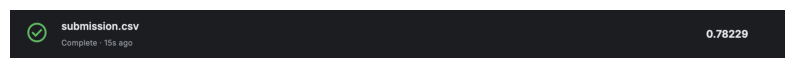

In [315]:
import matplotlib.image as mpimg
image = mpimg.imread(os.path.join(path, 'result.png'))
plt.figure(figsize=(10, 10), dpi=100)
plt.imshow(image)
plt.axis('off')